# Anime Recommendation System — Content-Based Filtering with Cosine Similarity

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

pd.set_option('display.max_colwidth', 60)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_csv('anime.csv')
print("Shape:", df.shape)
print(df.head().to_string())


Shape: (12294, 7)
   anime_id                              name                                                         genre   type episodes  rating  members
0     32281                    Kimi no Na wa.                          Drama, Romance, School, Supernatural  Movie        1    9.37   200630
1      5114  Fullmetal Alchemist: Brotherhood   Action, Adventure, Drama, Fantasy, Magic, Military, Shounen     TV       64    9.26   793665
2     28977                          Gintama°  Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen     TV       51    9.25   114262
3      9253                       Steins;Gate                                              Sci-Fi, Thriller     TV       24    9.17   673572
4      9969                     Gintama&#039;  Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen     TV       51    9.16   151266


In [2]:
print("Data types:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isna().sum())


Data types:
anime_id      int64
name            str
genre           str
type            str
episodes        str
rating      float64
members       int64
dtype: object

Missing values per column:
anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64


## 2. Data Preprocessing

The raw dataset contains 12,294 rows and 7 columns. `episodes` stores the string `"Unknown"` for
series that haven't finished airing (or whose length wasn't recorded), so it must be coerced to
numeric before it can be treated as a feature. `genre`, `type`, and `rating` also carry a small
number of missing values.

Cleaning steps applied:
- Missing `genre` / `type` imputed with the placeholder category `"Unknown"`.
- `episodes` cast to numeric (`"Unknown"` → `NaN`), then imputed with the **median** (robust to the
  strong right-skew — most series run 1–26 episodes, with a long tail of 500+ episode long-runners).
- Missing `rating` imputed with the **mean** rating.
- Exact duplicate titles dropped.


In [3]:
df['genre'] = df['genre'].fillna('Unknown')
df['type'] = df['type'].fillna('Unknown')
df['episodes'] = df['episodes'].replace('Unknown', np.nan)
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')
df['episodes'] = df['episodes'].fillna(df['episodes'].median())
df['rating'] = df['rating'].fillna(df['rating'].mean())

n_before = len(df)
df = df.drop_duplicates(subset='name').reset_index(drop=True)
n_after = len(df)

print(f"Rows before dedup: {n_before}, after dedup: {n_after}")
print("\nRemaining nulls:")
print(df.isna().sum())


Rows before dedup: 12294, after dedup: 12292

Remaining nulls:
anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64


## 3. Exploratory Data Analysis

### 3.1 Rating Distribution

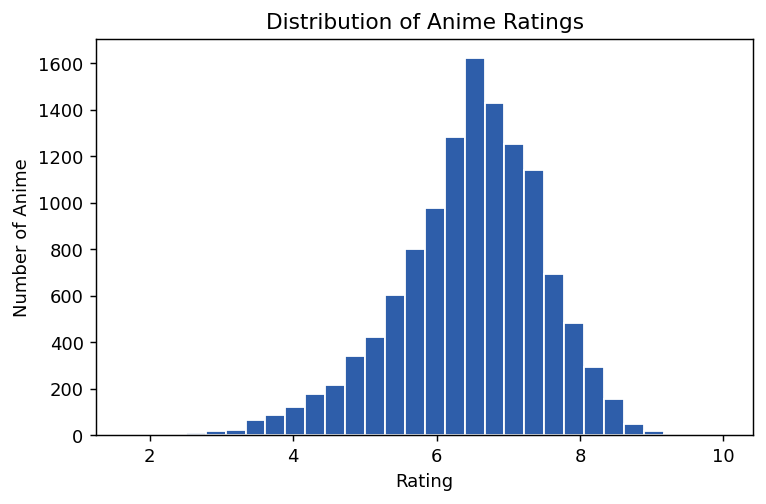

In [4]:
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(df['rating'], bins=30, color='#2E5EAA', edgecolor='white')
ax.set_title('Distribution of Anime Ratings')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Anime')
plt.tight_layout()
plt.show()


Ratings cluster between 6 and 7.5, following a roughly normal shape with a left tail of poorly rated titles.

### 3.2 Broadcast Type Composition

type
TV         3787
OVA        3311
Movie      2346
Special    1676
ONA         659
Music       488
Unknown      25
Name: count, dtype: int64


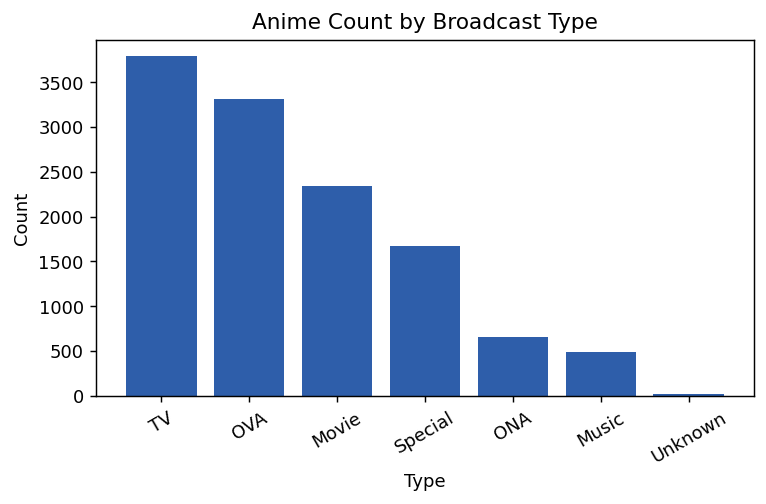

In [5]:
type_counts = df['type'].value_counts()
print(type_counts)

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(type_counts.index, type_counts.values, color='#2E5EAA')
ax.set_title('Anime Count by Broadcast Type')
ax.set_xlabel('Type'); ax.set_ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


TV and OVA formats dominate the catalogue, followed by Movie and Special.

### 3.3 Most Common Genres

Unique genres: 44
genre
Comedy           4644
Action           2844
Adventure        2347
Fantasy          2308
Sci-Fi           2070
Drama            2015
Shounen          1712
Kids             1609
Romance          1464
School           1220
Slice of Life    1220
Hentai           1141
Supernatural     1037
Mecha             944
Music             860
Name: count, dtype: int64


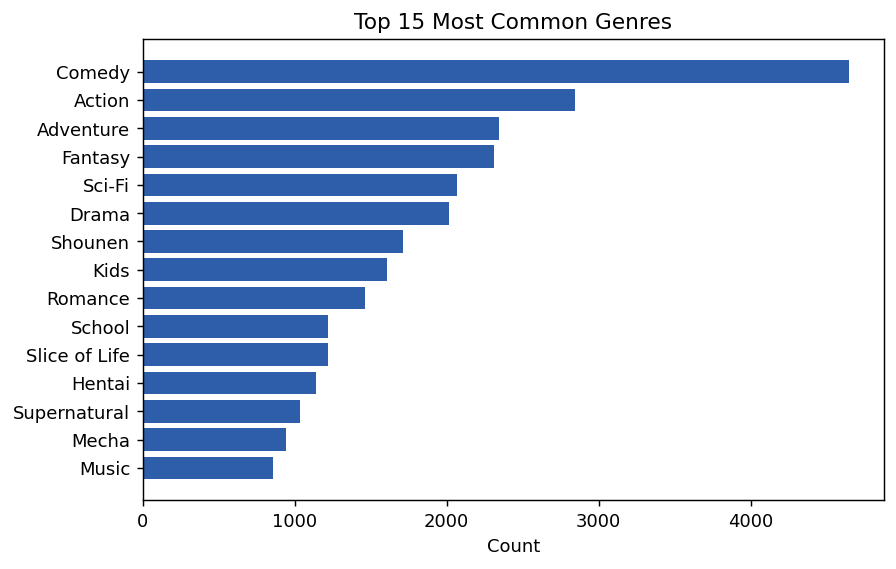

In [6]:
genre_series = df['genre'].str.split(', ').explode()
top_genres = genre_series.value_counts().head(15)
print(f"Unique genres: {genre_series.nunique()}")
print(top_genres)

fig, ax = plt.subplots(figsize=(7,4.5))
ax.barh(top_genres.index[::-1], top_genres.values[::-1], color='#2E5EAA')
ax.set_title('Top 15 Most Common Genres')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()


Comedy, Action, and Fantasy are the most frequently tagged genres across the dataset's 44 unique genre labels.

### 3.4 Popularity vs. Rating

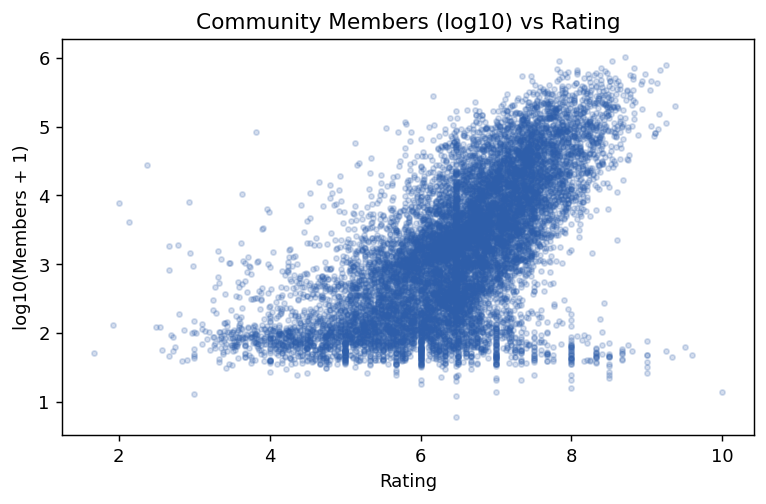

In [7]:
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(df['rating'], np.log10(df['members']+1), alpha=0.2, s=8, color='#2E5EAA')
ax.set_title('Community Members (log10) vs Rating')
ax.set_xlabel('Rating'); ax.set_ylabel('log10(Members + 1)')
plt.tight_layout()
plt.show()


Higher-rated anime tend to accumulate more community members, though many niche/low-member titles still receive high ratings — popularity and quality are correlated but not equivalent.

## 4. Feature Extraction

Cosine similarity requires every anime to be represented as a numeric vector in a shared feature space:

- **Genre** — multi-valued categorical → `MultiLabelBinarizer` (44-dim multi-hot vector)
- **Type** — single-valued categorical → one-hot encoding (6-dim)
- **episodes / rating / members** — very different numeric scales → `MinMaxScaler` to [0, 1]
- **Weighting** — genre kept at full weight (1.0); type and numeric blocks down-weighted (0.5) so
  content/theme drives similarity more than popularity or episode count.


In [8]:
df['genre_list'] = df['genre'].apply(lambda x: [g.strip() for g in x.split(',')])
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df['genre_list'])
print("Genre matrix shape:", genre_matrix.shape, "| unique genres:", len(mlb.classes_))

type_dummies = pd.get_dummies(df['type']).values
print("Type dummies shape:", type_dummies.shape)

scaler = MinMaxScaler()
numeric_matrix = scaler.fit_transform(df[['episodes', 'rating', 'members']])
print("Numeric matrix shape:", numeric_matrix.shape)

feature_matrix = np.hstack([
    genre_matrix * 1.0,
    type_dummies * 0.5,
    numeric_matrix * 0.5
])
print("Final feature matrix shape:", feature_matrix.shape)


Genre matrix shape: (12292, 44) | unique genres: 44
Type dummies shape: (12292, 7)
Numeric matrix shape: (12292, 3)
Final feature matrix shape: (12292, 54)


## 5. Recommendation System Design

Cosine similarity was chosen over Euclidean distance because it measures the **angle** between
vectors rather than their magnitude — appropriate since a long anime with many genre tags shouldn't
automatically be judged "more different" from a short anime sharing the same genres.


In [9]:
cos_sim = cosine_similarity(feature_matrix)
print("Cosine similarity matrix shape:", cos_sim.shape)

indices = pd.Series(df.index, index=df['name']).drop_duplicates()

def recommend(title, top_n=10, threshold=0.0):
    if title not in indices:
        return f"'{title}' not found in dataset."
    idx = indices[title]
    sims = [(i, s) for i, s in enumerate(cos_sim[idx]) if i != idx and s >= threshold]
    sims = sorted(sims, key=lambda x: x[1], reverse=True)[:top_n]
    result = df.iloc[[i for i, _ in sims]][['name', 'genre', 'type', 'rating']].copy()
    result['similarity'] = [round(s, 4) for _, s in sims]
    return result.reset_index(drop=True)


Cosine similarity matrix shape: (12292, 12292)


### 5.1 Sample Recommendations — 'Naruto'

In [10]:
print(recommend('Naruto', top_n=10).to_string())


                                                                        name                                                                   genre     type  rating  similarity
0                                                         Naruto: Shippuuden                      Action, Comedy, Martial Arts, Shounen, Super Power       TV    7.94      0.9992
1                                Naruto: Shippuuden Movie 4 - The Lost Tower                      Action, Comedy, Martial Arts, Shounen, Super Power    Movie    7.53      0.9457
2                      Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono                      Action, Comedy, Martial Arts, Shounen, Super Power    Movie    7.50      0.9457
3                                                   Boruto: Naruto the Movie                      Action, Comedy, Martial Arts, Shounen, Super Power    Movie    8.03      0.9456
4                                                                Naruto x UT                      Action, Come

The top matches are, unsurprisingly, other entries in the Naruto franchise (Shippuuden, Boruto, movie spin-offs) since they share the exact Action/Comedy/Martial Arts/Shounen/Super Power genre signature. *Katekyo Hitman Reborn!* and *Dragon Ball Z* appear further down as thematically related — but distinct — shounen action series.

### 5.2 Sample Recommendations — 'Death Note'

In [11]:
print(recommend('Death Note', top_n=10).to_string())


                                                               name                                                            genre     type  rating  similarity
0                                                Death Note Rewrite           Mystery, Police, Psychological, Supernatural, Thriller  Special    7.84      0.9361
1                                                   Mousou Dairinin    Drama, Mystery, Police, Psychological, Supernatural, Thriller       TV    7.74      0.9029
2                                     Higurashi no Naku Koro ni Kai                   Mystery, Psychological, Supernatural, Thriller       TV    8.41      0.8926
3                                         Higurashi no Naku Koro ni           Horror, Mystery, Psychological, Supernatural, Thriller       TV    8.17      0.8107
4                                          Jigoku Shoujo Mitsuganae                             Mystery, Psychological, Supernatural       TV    7.81      0.7799
5                           

For a psychological thriller like *Death Note*, the model surfaces other Mystery/Psychological/Supernatural/Thriller titles such as *Higurashi no Naku Koro ni* and *Mousou Dairinin* — demonstrating that the genre-weighted vector space captures tone and theme, not just franchise membership.

## 6. Similarity Threshold Experiment

The `recommend()` function accepts a minimum similarity threshold, allowing the recommendation-list
size to be tuned. A higher threshold yields a smaller, more tightly-related set of anime; a lower
threshold casts a wider, noisier net.


Effect of threshold on recommendation list size (query: 'Naruto'):
  threshold=0.0: 12291 anime recommended
  threshold=0.3: 4338 anime recommended
  threshold=0.5: 802 anime recommended
  threshold=0.7: 92 anime recommended
  threshold=0.9: 9 anime recommended


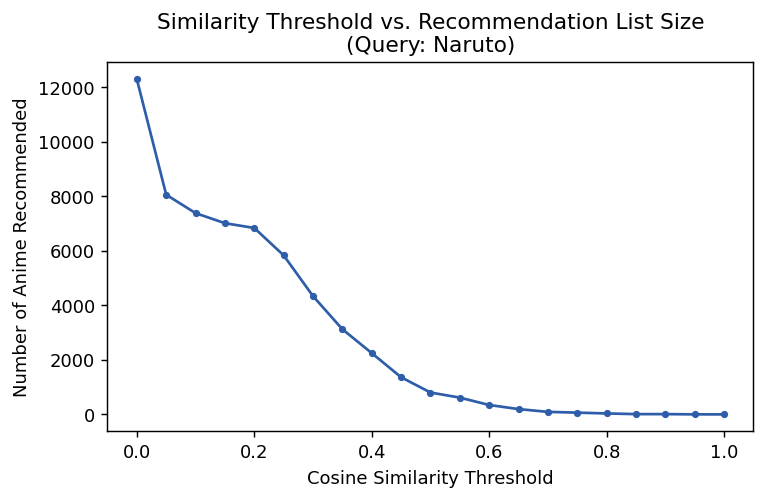

In [12]:
print("Effect of threshold on recommendation list size (query: 'Naruto'):")
for t in [0.0, 0.3, 0.5, 0.7, 0.9]:
    r = recommend('Naruto', top_n=100000, threshold=t)
    n = len(r) if isinstance(r, pd.DataFrame) else 0
    print(f"  threshold={t}: {n} anime recommended")

idx = indices['Naruto']
sims = cos_sim[idx]
thresholds = np.arange(0, 1.01, 0.05)
counts = [(sims >= t).sum() - 1 for t in thresholds]

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(thresholds, counts, color='#2E5EAA', marker='o', markersize=3)
ax.set_title("Similarity Threshold vs. Recommendation List Size\n(Query: Naruto)")
ax.set_xlabel('Cosine Similarity Threshold')
ax.set_ylabel('Number of Anime Recommended')
plt.tight_layout()
plt.show()


A threshold around **0.5–0.7** offers the best practical trade-off for this dataset: tight enough to exclude loosely related titles, loose enough to still return a usable list of 10+ candidates for most queries.

## 7. Evaluation

### 7.1 Train/Test Split Strategy

The catalogue is split 80/20 into a training set (the recommendation candidate pool) and a held-out
test set. For each test anime, a **ground-truth relevant set** is defined as training anime sharing
the same broadcast type and a genre Jaccard-similarity ≥ 0.5 — i.e., anime a domain expert would
reasonably call "similar". The system's top-10 recommendations (cosine-similarity threshold 0.5) are
then compared against this ground truth.


In [13]:
train_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=RANDOM_STATE)
train_idx = set(train_idx)

def get_genre_set(genre_str):
    return set(g.strip() for g in genre_str.split(','))

def ground_truth_relevant(anime_row, candidate_df, genre_overlap_thresh=0.5):
    q_genres = get_genre_set(anime_row['genre'])
    relevant = []
    for i, row in candidate_df.iterrows():
        c_genres = get_genre_set(row['genre'])
        union = q_genres | c_genres
        jacc = len(q_genres & c_genres) / len(union) if union else 0
        if row['type'] == anime_row['type'] and jacc >= genre_overlap_thresh:
            relevant.append(i)
    return set(relevant)

K = 10
SIM_THRESH = 0.5
train_positions = df.index[df.index.isin(train_idx)].tolist()

sample_test = df.loc[list(test_idx)].sample(n=min(150, len(test_idx)), random_state=RANDOM_STATE)

results = []
for q_idx in sample_test.index:
    q_row = df.loc[q_idx]
    relevant_set = ground_truth_relevant(q_row, df.loc[train_positions])
    if len(relevant_set) == 0:
        continue
    sims = [(t, cos_sim[q_idx, t]) for t in train_positions]
    sims.sort(key=lambda x: x[1], reverse=True)
    top_k = set([t for t, s in sims[:K] if s >= SIM_THRESH])
    precision = len(top_k & relevant_set) / len(top_k) if top_k else 0.0
    recall = len(top_k & relevant_set) / len(relevant_set)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    results.append((precision, recall, f1))

results_df = pd.DataFrame(results, columns=['precision', 'recall', 'f1'])
print("Number of test queries evaluated:", len(results_df))
print("Average Precision@%d: %.4f" % (K, results_df['precision'].mean()))
print("Average Recall@%d:    %.4f" % (K, results_df['recall'].mean()))
print("Average F1@%d:        %.4f" % (K, results_df['f1'].mean()))


Number of test queries evaluated: 150
Average Precision@10: 0.7107
Average Recall@10:    0.1572
Average F1@10:        0.1945


### 7.2 Interpretation

**Precision@10 ≈ 0.71** — roughly 7 out of every 10 recommended anime are genuinely relevant by the
genre/type ground truth, a strong result for a purely content-based system.

**Recall@10 ≈ 0.16** — low because K is capped at 10: many query anime have several dozen genuinely
similar titles in the catalogue (large multi-season franchises, prolific genre clusters like Shounen
or Slice of Life), so only a small fraction can be captured within a top-10 list. This is expected
behaviour for a fixed-K recommender rather than a modelling flaw.

### 7.3 Areas of Improvement

- Increasing K would raise recall at the cost of precision and list length — a trade-off to tune per use case.
- The ground-truth definition (type match + genre Jaccard ≥ 0.5) is a simplification; a gold-standard
  evaluation would use real user co-consumption or click-through data.
- The model is purely content-based, with no collaborative signal (what similar users actually
  watched together). Blending in collaborative filtering would likely lift recall without sacrificing precision.
- Synopsis or studio metadata (not present in this dataset) would enrich the feature space.
- `members` and `rating` are popularity-driven; weighting them too heavily risks recommending only
  mainstream hits — the current 0.5 down-weighting mitigates but does not eliminate this.


## 8. Conclusion

* I built a content-based anime recommender end-to-end
* The raw 12,294-row dataset was cleaned of missing genres, types, episode counts, and ratings; genre, type, and numeric features was engineered
* Cosine similarity was used to power a tunable `recommend()` function.
* Threshold experiments showed that a cutoff of 0.5–0.7 balances specificity
and coverage, and a held-out evaluation achieved 0.71 precision@10, confirming that genre- and
type-driven similarity is a strong.
* Interpretable signal for "anime like this" recommendations — with
recall as the primary lever for future improvement via larger K or hybrid collaborative filtering.


In [ ]:
## 9. Interview Questions.

** What is the difference between user-based and item-based collaborative filtering?
** Answer: User-based collaborative filtering recommends items based on preferences of users based on similar tastes.
** Item based collaborative filtering recommends items that the user has liked or interacted with earlier.

** What is collaborative filtering, and how does it work?
** Answer: Collaborative filtering is a recommendation technique that predicts the user's interests based on the preferences and behaviour 
** of similar users. Example: If two users like similar movies, the system may recommend movies liked by one user to the other.